In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import shap
import warnings
warnings.filterwarnings('ignore')

# Load model and data
with open('models/xgb_churn_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('models/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

df = pd.read_csv('data/processed/telco_churn_processed.csv')
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Model loaded. Features: {len(feature_names)}")
print(f"Data shape: {X.shape}")

Model loaded. Features: 31
Data shape: (7043, 31)


In [2]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP explainer ready.")

SHAP values shape: (7043, 31)
SHAP explainer ready.


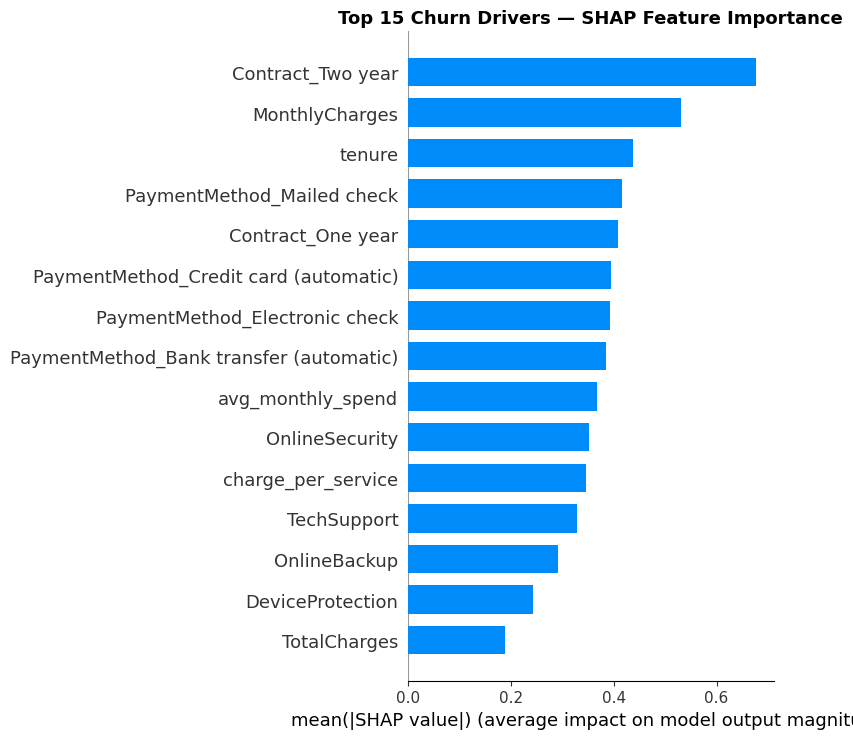

Saved: shap_importance_bar.png


In [3]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, plot_type="bar",
                  feature_names=feature_names,
                  max_display=15, show=False)
plt.title('Top 15 Churn Drivers — SHAP Feature Importance',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_importance_bar.png")

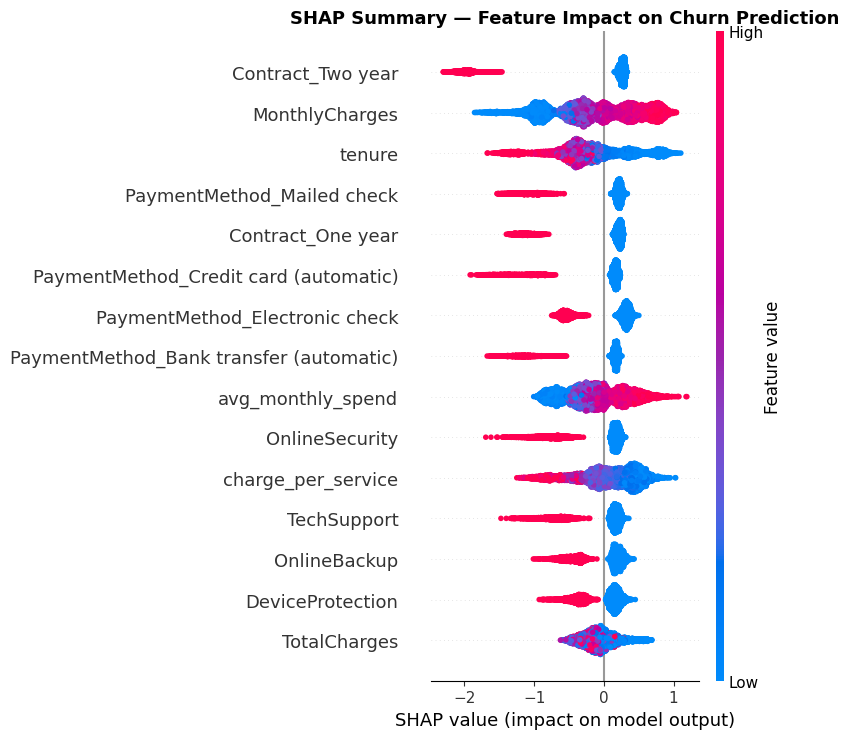

Saved: shap_summary_beeswarm.png


In [4]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X,
                  feature_names=feature_names,
                  max_display=15, show=False)
plt.title('SHAP Summary — Feature Impact on Churn Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_beeswarm.png")

Explaining customer at index: 4
Churn probability: 0.785
Actual churn: 1


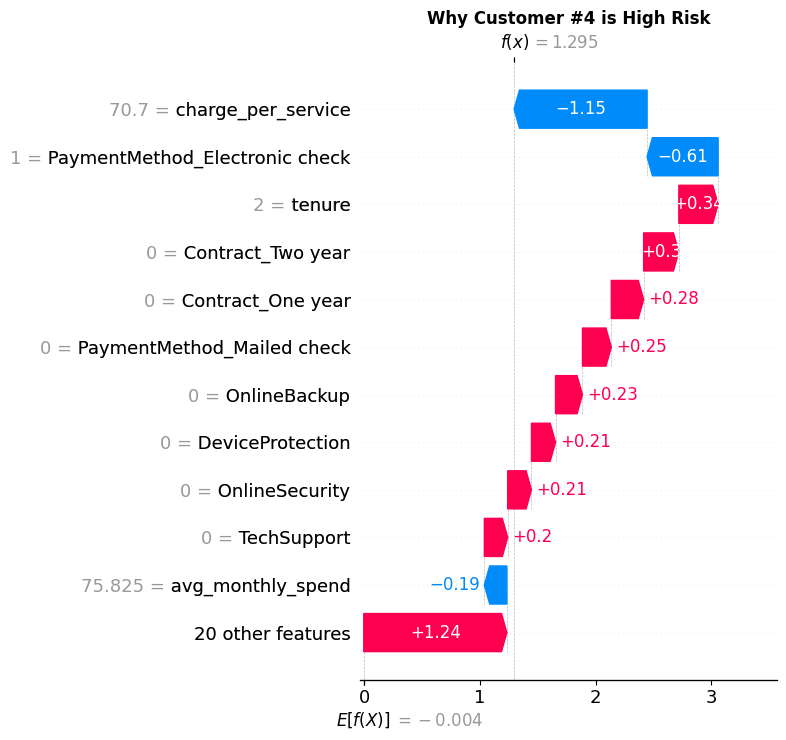

In [5]:
# Explain a high-risk customer (find one predicted as churn)
with open('models/optimal_threshold.pkl', 'rb') as f:
    threshold = pickle.load(f)

y_prob = model.predict_proba(X)[:, 1]
high_risk_idx = np.where(y_prob > 0.7)[0][0]  # First high-risk customer

print(f"Explaining customer at index: {high_risk_idx}")
print(f"Churn probability: {y_prob[high_risk_idx]:.3f}")
print(f"Actual churn: {y.iloc[high_risk_idx]}")

# Waterfall plot for this customer
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X.iloc[high_risk_idx],
        feature_names=feature_names
    ),
    max_display=12,
    show=False
)
plt.title(f'Why Customer #{high_risk_idx} is High Risk',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/shap_waterfall_highrisk.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Save SHAP values for Streamlit app
shap_df = pd.DataFrame(shap_values, columns=feature_names)
shap_df.to_csv('data/processed/shap_values.csv', index=False)

# Save top 10 features by mean absolute SHAP
mean_shap = pd.DataFrame({
    'feature': feature_names,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

top_features = mean_shap.head(10)
top_features.to_csv('data/processed/top_shap_features.csv', index=False)

print("Top 10 Churn Drivers:")
print(top_features.to_string(index=False))

Top 10 Churn Drivers:
                                feature  importance
                      Contract_Two year    0.677103
                         MonthlyCharges    0.529860
                                 tenure    0.438390
             PaymentMethod_Mailed check    0.416002
                      Contract_One year    0.408750
  PaymentMethod_Credit card (automatic)    0.394029
         PaymentMethod_Electronic check    0.392499
PaymentMethod_Bank transfer (automatic)    0.385823
                      avg_monthly_spend    0.366754
                         OnlineSecurity    0.351773


In [7]:
df_full = pd.read_csv('data/processed/telco_churn_full.csv')

# Add model predictions
X_full = df_full.drop(columns=['Churn', 'customerID', 'tenure_group',
                                'heuristic_risk', 'value_segment', 'LTV'],
                       errors='ignore')
X_full = X_full[feature_names]  # Ensure correct column order

churn_prob = model.predict_proba(X_full)[:, 1]
df_full['churn_probability'] = churn_prob
df_full['churn_prediction'] = (churn_prob >= threshold).astype(int)

# Risk segments based on model probability
def assign_risk(prob):
    if prob >= 0.70:
        return 'High Risk'
    elif prob >= 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_full['risk_level'] = df_full['churn_probability'].apply(assign_risk)

print(df_full['risk_level'].value_counts())
print(f"\nHigh risk customers: {(df_full['risk_level']=='High Risk').sum()}")
print(f"Revenue at risk: ${(df_full[df_full['risk_level']=='High Risk']['MonthlyCharges'].sum()):,.0f}/month")

df_full.to_csv('data/processed/telco_churn_scored.csv', index=False)
print("\nScored dataset saved.")

risk_level
Low Risk       4700
Medium Risk    1278
High Risk      1065
Name: count, dtype: int64

High risk customers: 1065
Revenue at risk: $81,605/month

Scored dataset saved.
